# 05. Pandas 고급 분석 - 실습 문제

## 실습 안내
- 총 10개 문제
- 시계열 분석, 이동평균, OEE, SPC 등 실무 분석
- 종합적인 제조 데이터 분석 능력 배양
- 실제 공장 모니터링 대시보드 구축

## 데이터 로드 및 전처리

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 데이터 불러오기
production_df = pd.read_csv('../data/05_production.csv', encoding='utf-8-sig')
quality_df = pd.read_csv('../data/07_quality_inspection.csv', encoding='utf-8-sig', na_values=['\\N'])
sensor_df = pd.read_csv('../data/08_sensor_data.csv', encoding='utf-8-sig')
operation_df = pd.read_csv('../data/06_equipment_operation.csv', encoding='utf-8-sig')
equipment_df = pd.read_csv('../data/01_equipment.csv', encoding='utf-8-sig')
maintenance_df = pd.read_csv('../data/10_maintenance_history.csv', encoding='utf-8-sig')

# 날짜/시간 변환
production_df['production_date'] = pd.to_datetime(production_df['production_date'])
production_df['start_time'] = pd.to_datetime(production_df['start_time'])
production_df['end_time'] = pd.to_datetime(production_df['end_time'])
quality_df['inspection_time'] = pd.to_datetime(quality_df['inspection_time'])
sensor_df['measurement_time'] = pd.to_datetime(sensor_df['measurement_time'])
operation_df['start_time'] = pd.to_datetime(operation_df['start_time'])
operation_df['end_time'] = pd.to_datetime(operation_df['end_time'])

print("데이터 로드 완료!")

데이터 로드 완료!


---
## 문제 1: 일별 생산량 추이 분석

**시나리오**: 일별 생산량 추이를 분석하여 생산 패턴을 파악하세요.

**요구사항**:
1. 일별로 다음 집계:
   - 생산 건수
   - 총 생산량
   - 총 불량수
   - 불량률 (%)
2. 처음 30일 데이터 출력
3. 불량률이 가장 높았던 날 찾기

**힌트**: `groupby('production_date')`, 계산 컬럼, `idxmax()`

In [2]:
production_df.columns

Index(['production_id', 'equipment_id', 'product_code', 'production_date',
       'start_time', 'end_time', 'target_quantity', 'actual_quantity',
       'good_quantity', 'defect_quantity', 'cycle_time', 'work_order_no',
       'lot_no', 'operator_id', 'shift', 'created_at', 'updated_at'],
      dtype='object')

In [145]:
# 여기에 코드 작성
production_df['불량률'] = (production_df['defect_quantity'] / production_df['actual_quantity'] * 100).round(2)
prod_day1 = production_df.groupby('production_date').agg({'production_id':'count',
                                              'actual_quantity':'sum',
                                              'defect_quantity':'sum',
                                              '불량률':'mean'}).reset_index()

In [146]:
prod_day1.columns = ['날짜', '생산건수', '총생산량', '총불량수', '불량률']
prod_day1.sort_values('불량률', ascending = False).reset_index(drop = True).iloc[0]['날짜']

Timestamp('2024-03-27 00:00:00')

In [147]:
prod_day1.sort_values('불량률', ascending = False)

,날짜,생산건수,총생산량,총불량수,불량률
86,2024-03-27,22,2496,386,15.625455
88,2024-03-29,22,2551,391,15.384545
78,2024-03-19,18,2061,312,15.285556
77,2024-03-18,24,2335,355,15.240000
48,2024-02-18,20,2222,336,15.227000
...,...,...,...,...,...
9,2024-01-10,22,2491,126,5.131818
43,2024-02-13,20,2277,115,5.126500
31,2024-02-01,18,2041,104,5.111111
29,2024-01-30,22,2561,128,5.110455


---
## 문제 2: 센서 데이터 시간별 리샘플링

**시나리오**: INJ-001 설비의 센서 데이터를 시간 단위로 집계하세요.

**요구사항**:
1. sensor_df에서 equipment_id='INJ-001'인 데이터 필터링
2. measurement_time을 인덱스로 설정
3. 4시간 단위로 리샘플링하여 다음 집계:
   - temperature: 평균
   - pressure: 평균
   - vibration: 최대값
4. 처음 20개 결과 출력

**힌트**: `set_index()`, `resample('4H')`, `agg()`

In [154]:
# 여기에 코드 작성
sensor_inj = sensor_df[sensor_df['equipment_id'] == 'INJ-001'].copy()
sensor_inj_4h = sensor_inj.set_index('measurement_time').resample('4h').agg({'temperature' : 'mean', 
                                                             'pressure' : 'mean', 
                                                             'vibration' : 'max'})
sensor_inj_4h.columns = ['온도평균', '압력평균', '진동최대']
sensor_inj_4h

,온도평균,압력평균,진동최대
measurement_time,,,
2024-01-01 00:00:00,181.0675,148.4750,2.6838
2024-01-01 04:00:00,179.9775,152.6550,2.5944
2024-01-01 08:00:00,182.5850,146.1700,2.5428
2024-01-01 12:00:00,179.0150,148.1275,2.8046
2024-01-01 16:00:00,180.3300,151.4825,2.6443
...,...,...,...
2024-03-31 04:00:00,195.0375,150.0700,2.6603
2024-03-31 08:00:00,196.2525,148.4250,2.6910
2024-03-31 12:00:00,196.1975,149.1400,2.7700


In [155]:
sensor_inj_4h.describe()

,온도평균,압력평균,진동최대
count,546.000000,546.000000,546.000000
mean,187.510234,150.021749,2.712864
std,4.485113,1.669221,0.149729
min,178.235000,144.862500,2.324300
25%,183.773125,148.903125,2.607200
50%,187.467500,150.037500,2.697100
75%,191.346875,151.153125,2.808000
max,197.247500,155.272500,3.251700


In [160]:
sensor_inj_4h.loc[sensor_inj_4h['온도평균'].idxmax()]

온도평균    197.2475
압력평균    153.5500
진동최대      2.9808
Name: 2024-03-31 00:00:00, dtype: float64

In [158]:
sensor_inj_4h[sensor_inj_4h['온도평균'] == 197.247500]

,온도평균,압력평균,진동최대
measurement_time,,,
2024-03-31,197.2475,153.55,2.9808


---
## 문제 3: 생산량 이동평균 계산

**시나리오**: 일별 생산량에 이동평균을 적용하여 추세를 파악하세요.

**요구사항**:
1. 일별 총 생산량 집계
2. 7일 이동평균 계산
3. 30일 이동평균 계산
4. 원본, 7일MA, 30일MA를 함께 출력 (처음 60일)
5. 이동평균이 실제 생산량보다 높은 날 (하락 추세) 찾기

**힌트**: `rolling(window=n).mean()`, 비교 연산

In [179]:
# 여기에 코드 작성
daily_qty = production_df.groupby('production_date')['actual_quantity'].sum()
prod_ma7 = production_df.set_index('production_date').resample('D')['actual_quantity'].sum().rolling(window = 7).mean()
prod_ma30 = production_df.set_index('production_date').resample('D')['actual_quantity'].sum().rolling(window = 30).mean()

In [176]:
prod_ma7 = daily_qty.rolling(window=7).mean()
prod_ma30 = daily_qty.rolling(window=30).mean()

In [184]:
prod_all = pd.concat( [daily_qty, prod_ma7, prod_ma30], axis = 1)
prod_all.columns = ['원본', '7일MA', '30일MA']
prod_all.head(60)

,원본,7일MA,30일MA
production_date,,,
2024-01-01,2019,NaN,NaN
2024-01-02,2380,NaN,NaN
2024-01-03,1848,NaN,NaN
2024-01-04,2358,NaN,NaN
2024-01-05,2330,NaN,NaN
2024-01-06,2503,NaN,NaN
2024-01-07,2831,2324.142857,NaN
2024-01-08,2471,2388.714286,NaN
2024-01-09,2210,2364.428571,NaN


In [185]:
desc_trend = prod_all.loc[prod_all['7일MA'] > prod_all['원본'], ['원본', '7일MA']]
desc_trend.head()

,원본,7일MA
production_date,,
2024-01-09,2210,2364.428571
2024-01-11,2254,2441.428571
2024-01-12,2376,2448.000000
2024-01-13,2325,2422.571429
2024-01-14,2168,2327.857143


---
## 문제 4: 전일 대비 생산량 변화 분석

**시나리오**: 일별 생산량의 전일 대비 변화를 분석하세요.

**요구사항**:
1. 일별 총 생산량 집계
2. 전일 생산량 추가 (`shift()`)
3. 전일 대비 증감량 계산 (`diff()`)
4. 전일 대비 변화율(%) 계산 (`pct_change()`)
5. 변화율이 가장 큰 날(증가) 상위 5개 출력
6. 변화율이 가장 작은 날(감소) 상위 5개 출력

**힌트**: shift, diff, pct_change, sort_values

In [60]:
# 여기에 코드 작성
prod_day = production_df.groupby('production_date')['actual_quantity'].sum()
전일생산량 = prod_day.shift()
전일증감량 = prod_day.diff()
전일변화율 = prod_day.pct_change() * 100

In [67]:
prod_change = pd.concat([prod_day, 전일생산량, 전일증감량, 전일변화율], axis = 1)

In [71]:
prod_change.columns = ['생산량', '전일생산량', '전일증감량', '전일변화율']

In [76]:
prod_change.sort_values('전일변화율')

,생산량,전일생산량,전일증감량,전일변화율
production_date,,,,
2024-01-20,1722,2515.0,-793.0,-31.530815
2024-01-17,1813,2513.0,-700.0,-27.855153
2024-02-04,1861,2443.0,-582.0,-23.823168
2024-01-03,1848,2380.0,-532.0,-22.352941
2024-03-22,1946,2440.0,-494.0,-20.245902
...,...,...,...,...
2024-03-02,2781,2111.0,670.0,31.738513
2024-01-21,2282,1722.0,560.0,32.520325
2024-01-18,2496,1813.0,683.0,37.672366


In [254]:
변화율증가_top5 = prod_change.sort_values('전일변화율', ascending = False)[:5]
변화율감소_top5 = prod_change.sort_values('전일변화율')[:5]

In [255]:
변화율증가_top5

,생산량,전일생산량,전일증감량,전일변화율
production_date,,,,
2024-02-05,2684,1861.0,823.0,44.223536
2024-01-18,2496,1813.0,683.0,37.672366
2024-01-21,2282,1722.0,560.0,32.520325
2024-03-02,2781,2111.0,670.0,31.738513
2024-03-09,2433,1876.0,557.0,29.690832


In [256]:
변화율감소_top5

,생산량,전일생산량,전일증감량,전일변화율
production_date,,,,
2024-01-20,1722,2515.0,-793.0,-31.530815
2024-01-17,1813,2513.0,-700.0,-27.855153
2024-02-04,1861,2443.0,-582.0,-23.823168
2024-01-03,1848,2380.0,-532.0,-22.352941
2024-03-22,1946,2440.0,-494.0,-20.245902


---
## 문제 5: 센서 데이터 이상치 탐지 (3-Sigma)

**시나리오**: PRESS-001 설비의 압력 센서 이상치를 탐지하세요.

**요구사항**:
1. sensor_df에서 equipment_id='PRESS-001' 필터링
2. pressure 컬럼의 평균과 표준편차 계산
3. 3-Sigma 방식으로 상한/하한 계산:
   - 하한 = 평균 - 3×표준편차
   - 상한 = 평균 + 3×표준편차
4. 이상치 플래그 컬럼 생성
5. 이상치 건수 및 비율 출력
6. 이상치 데이터 처음 10개 출력

**힌트**: mean(), std(), 조건 연산

In [102]:
def get_anomaly(x):
    if x < lower or x > upper:
        return 1
    else:
        return 0

In [297]:
# 여기에 코드 작성
sensor_prs = sensor_df[sensor_df['equipment_id'] == 'PRESS-001'].copy()
pressure_mean = sensor_prs['pressure'].mean()
pressure_std = sensor_prs['pressure'].std()
upper = pressure_mean + 3*pressure_std
lower = pressure_mean - 3*pressure_std
print(f'상한 : {upper:.2f}, 하한 : {lower:.2f}')
sensor_prs['이상치유무'] = sensor_prs['pressure'].apply(get_anomaly)
print(f'이상치 건 수 : {sensor_prs['이상치유무'].sum()}')
print(f'이상치 비율 : {sensor_prs['이상치유무'].sum() / sensor_prs.shape[0]:.5f}')

상한 : 210.13, 하한 : 189.80
이상치 건 수 : 6
이상치 비율 : 0.00275


In [107]:
sensor_prs[sensor_prs['이상치유무'] == 1]

,sensor_id,equipment_id,measurement_time,temperature,pressure,vibration,current,voltage,rpm,created_at,이상치유무
827,828,PRESS-001,2024-01-07 21:00:00,83.32,212.63,3.1379,117.29,383.67,458.46,2026-01-30 00:45:52,1
1467,1468,PRESS-001,2024-01-13 05:00:00,83.58,210.36,3.5575,119.84,377.42,490.40,2026-01-30 00:45:52,1
4427,4428,PRESS-001,2024-02-06 21:00:00,81.04,212.10,3.2676,123.47,383.09,503.62,2026-01-30 00:45:52,1
5402,5403,PRESS-001,2024-02-15 00:00:00,81.97,211.25,3.6710,119.35,381.96,486.34,2026-01-30 00:45:52,1
5997,5998,PRESS-001,2024-02-19 23:00:00,83.74,188.69,3.8420,118.22,377.65,521.25,2026-01-30 00:45:52,1
6862,6863,PRESS-001,2024-02-27 04:00:00,85.74,210.45,3.5355,124.14,388.72,495.46,2026-01-30 00:45:52,1


---
## 문제 6: OEE (Overall Equipment Effectiveness) 계산

**시나리오**: 생산 데이터에서 설비별 OEE를 계산하세요.

**요구사항**:
1. production_df에서 다음 계산:
   - 양품률 = good_quantity / actual_quantity
   - 실제 작업시간(분) = (end_time - start_time)
   - 성능률 = (actual_quantity × cycle_time) / 실제작업시간
   - 가동률 = 1.0 (간소화)
   - OEE = 가동률 × 성능률 × 양품률 × 100
2. 설비별 평균 OEE 계산
3. OEE 순위 출력 (높은 순)
4. OEE가 70% 미만인 설비 찾기

**힌트**: 시간 차이 계산, 복합 계산, groupby

In [314]:
# 여기에 코드 작성
production_df['양품률'] = production_df['good_quantity'] / production_df['actual_quantity'] * 100
production_df['실제작업시간'] = (production_df['end_time'] - production_df['start_time']).dt.total_seconds() / 60
production_df['성능률'] = production_df['actual_quantity'] * (production_df['cycle_time'] / 60) / production_df['실제작업시간']
production_df['성능률'] = production_df['성능률'].clip(upper=1.0)
production_df['가동률'] = 1.0
production_df['OEE'] = production_df['가동률'] * production_df['성능률'] * production_df['양품률']

In [315]:
equip_OEE = production_df.groupby('equipment_id')['OEE'].mean()
equip_OEE

equipment_id
ASM-001      87.882984
INJ-001      89.240830
INJ-002      91.298427
PRESS-001    90.088489
PRESS-002    89.324051
Name: OEE, dtype: float64

---
## 문제 7: SPC 관리도 데이터 생성

**시나리오**: DASH-C 제품의 측정값에 대한 SPC X-bar 관리도를 생성하세요.

**요구사항**:
1. quality_df에서 product_code='DASH-C' 필터링
2. 일별로 measurement_value의 평균, 최소, 최대, 표준편차 계산
3. 전체 일별 평균의 중심선(CL) 계산
4. 관리상한선(UCL) = CL + 3×표준편차
5. 관리하한선(LCL) = CL - 3×표준편차
6. 관리 이탈 일자 찾기 (평균이 UCL 초과 또는 LCL 미만)
7. 처음 20일 데이터 출력

**힌트**: 날짜 추출, groupby, 통계 계산, 조건 필터링

In [205]:
# 여기에 코드 작성
quality_dash = quality_df[quality_df['product_code'] == 'DASH-C']
quality_dash.head(2)

,inspection_id,production_id,equipment_id,product_code,inspection_time,inspection_type,result,defect_code,measurement_value,measurement_unit,inspector_id,lot_no,sample_size,notes,created_at
37,38,4,INJ-002,DASH-C,2024-01-01 13:12:49,FINAL,PASS,NaN,399.6176,mm,OP007,LOT2024010100202,1,NaN,2026-01-30 01:24:59
38,39,4,INJ-002,DASH-C,2024-01-01 13:17:56,FINAL,PASS,NaN,400.6489,mm,OP007,LOT2024010100202,1,NaN,2026-01-30 01:24:59


In [324]:
quality_dash_day = quality_dash.set_index('inspection_time').resample('D').agg({'measurement_value' : ['mean', 'min', 'max', 'std']})
quality_dash_day.columns = [
    '측정평균',
    '측정최소',
    '측정최대',
    '측정표준편차'
]
quality_dash_day.reset_index(inplace = True)

In [327]:
quality_dash_day

,inspection_time,측정평균,측정최소,측정최대,측정표준편차
0,2024-01-01,400.528934,385.7846,414.0042,6.137162
1,2024-01-02,399.221975,385.1135,414.5393,6.856594
2,2024-01-03,399.316374,385.1084,414.2250,7.106159
3,2024-01-04,401.063721,385.3118,414.8666,6.620397
4,2024-01-05,400.289305,385.2997,414.4461,6.550703
...,...,...,...,...,...
87,2024-03-28,401.512352,385.6644,414.4740,8.707706
88,2024-03-29,399.344362,385.0789,414.6804,9.058132
89,2024-03-30,398.840839,385.3768,414.4562,8.287358
90,2024-03-31,401.125135,385.1726,414.6916,8.315482


In [337]:
cl = quality_dash_day['측정평균'].mean()
stds = quality_dash_day['측정평균'].std()
ucl = cl + 3 * stds
lcl = cl - 3 * stds
print(f'CL : {cl:.2f}\nSTD : {stds:.2f}\nUCL : {ucl:.2f}\nLCL : {lcl:.2f}')

CL : 400.04
STD : 0.76
UCL : 402.31
LCL : 397.77


In [336]:
quality_dash_day['관리상태'] = 'OK'
quality_dash_day.loc[quality_dash_day['측정평균'] > ucl, '관리상태'] = 'UCL초과'
quality_dash_day.loc[quality_dash_day['측정평균'] < lcl, '관리상태'] = 'LCL미만'

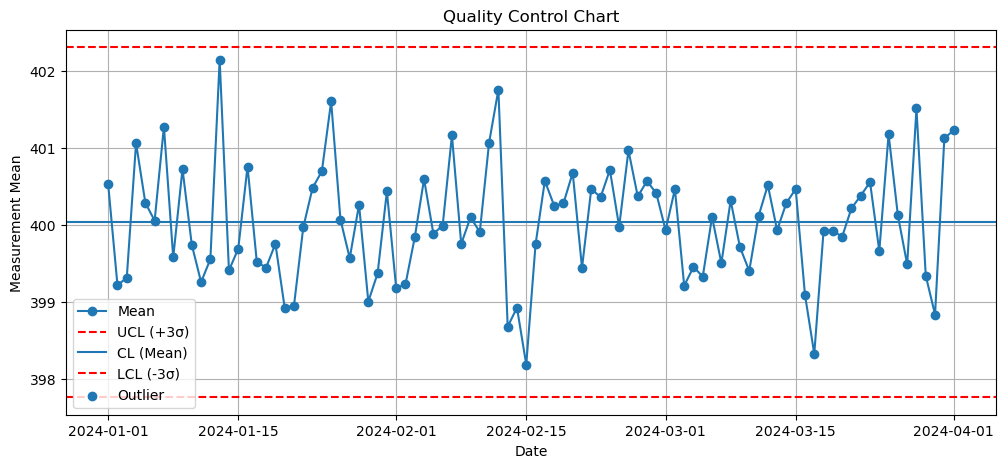

In [338]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 측정 평균 시계열
plt.plot(
    quality_dash_day['inspection_time'],
    quality_dash_day['측정평균'],
    label='Mean',
    marker='o'
)

# 관리 한계선
plt.axhline(ucl, linestyle='--', label='UCL (+3σ)', color = 'red')
plt.axhline(cl,  linestyle='-',  label='CL (Mean)')
plt.axhline(lcl, linestyle='--', label='LCL (-3σ)', color = 'red')

# 이상치 포인트 강조
outliers = quality_dash_day[
    (quality_dash_day['측정평균'] > ucl) |
    (quality_dash_day['측정평균'] < lcl)
]

plt.scatter(
    outliers['inspection_time'],
    outliers['측정평균'],
    label='Outlier',
    zorder=5
)

plt.xlabel('Date')
plt.ylabel('Measurement Mean')
plt.title('Quality Control Chart')
plt.legend()
plt.grid(True)

plt.show()


---
## 문제 8: 월별 생산 트렌드 및 변화율 분석

**시나리오**: 월별 생산 추이와 전월 대비 변화율을 분석하세요.

**요구사항**:
1. production_date에서 년-월 추출
2. 월별로 다음 집계:
   - 생산 건수
   - 총 생산량
   - 평균 불량률
   - 설비 가동 수 (equipment_id unique count)
3. 전월 대비 생산량 변화율(%) 계산
4. 전월 대비 불량률 변화(차이) 계산
5. 처음 12개월 데이터 출력

**힌트**: `dt.to_period('M')`, pct_change, diff

In [190]:
# 여기에 코드 작성
production_df['month'] = production_df['production_date'].dt.to_period('M')

In [343]:
production_m = production_df.groupby('month').agg({'production_id' : 'count',
                                    'actual_quantity' : 'sum',
                                    '불량률' : 'mean',
                                    'equipment_id' : lambda x : len(x.unique())}) # unique
production_m.columns = ['생산건수', '총생산량', '평균불량률', '설비가동수']
production_m.reset_index()
production_m['생산량변화율(%)'] = (production_m['총생산량'].pct_change() * 100).round(2)
production_m['불량률변화(%)'] = (production_m['평균불량률'].diff()).round(2)

In [344]:
production_m

,생산건수,총생산량,평균불량률,설비가동수,생산량변화율(%),불량률변화(%)
month,,,,,,
2024-01,626,69849,5.304601,5,NaN,NaN
2024-02,602,66390,10.364003,5,-4.95,5.06
2024-03,644,70365,14.871227,5,5.99,4.51


---
## 문제 9: 설비 고장 예측을 위한 특성 생성

**시나리오**: 설비 정비 이력과 생산/센서 데이터를 결합하여 고장 예측 특성을 생성하세요.

**요구사항**:
1. 설비별 정비 이력 집계:
   - 총 정비 건수
   - 총 정지 시간
   - 고장 정비 건수 (maintenance_type='BREAKDOWN')
2. 설비별 생산 집계:
   - 평균 사이클 타임
   - 평균 불량률
3. 설비별 센서 집계 (최근 30일):
   - 평균 온도
   - 평균 진동
   - 온도 표준편차
4. equipment_df에 위 세 집계를 모두 결합
5. 위험도 점수 계산:
   - 위험도 = (고장건수 × 10) + (평균불량률 × 5) + (온도표준편차 × 2)
6. 위험도 상위 5개 설비 출력

**힌트**: 각각 집계 후 순차적 merge, 복합 계산

In [357]:
# 여기에 코드 작성
equip_main = maintenance_df.groupby('equipment_id').agg({'maintenance_type' : ['count',lambda x : (x=='BREAKDOWN').sum()] ,
                                            'downtime_hours' : 'sum'}).reset_index()
equip_main.columns = ['equipment_id', '총정비건수', '고장정비건수', '총정지시간']


equip_prod = production_df.groupby('equipment_id').agg({'cycle_time' : 'mean',
                                           '불량률' : 'mean'}).reset_index()
equip_prod.columns = ['equipment_id','평균사이클타임', '평균불량률']


start_time = sensor_df['measurement_time'].max() - pd.Timedelta(days = 30)
sensor_df_30 = sensor_df[sensor_df['measurement_time'] >= start_time]
equip_sensor = sensor_df_30.groupby('equipment_id').agg({'temperature' : ['mean', 'std'],
                                       'vibration' : 'mean'}).reset_index()
equip_sensor.columns = ['equipment_id','평균온도', '온도표준편차', '평균진동']

In [358]:
equip_info = pd.merge(equipment_df, equip_main, how = 'left', on = 'equipment_id')
equip_info= pd.merge(equip_info, equip_prod, how = 'left', on = 'equipment_id')
equip_info = pd.merge(equip_info, equip_sensor, how = 'left', on = 'equipment_id')

In [359]:
equip_sensor

,equipment_id,평균온도,온도표준편차,평균진동
0,ASM-001,25.020083,2.240454,1.195913
1,INJ-001,192.543953,2.553721,2.499277
2,INJ-002,174.934008,2.234313,2.286726
3,PRESS-001,85.051318,2.198870,3.493685
4,PRESS-002,88.093953,2.099186,4.080482


In [360]:
equip_info['위험도'] = (equip_info['고장정비건수'] * 10) + (equip_info['평균불량률'] * 5) + (equip_info['온도표준편차'] * 2)

In [361]:
equip_info.nlargest(5, '위험도')

,equipment_id,equipment_name,equipment_type,location,rated_capacity,installation_date,status,created_at,updated_at,총정비건수,고장정비건수,총정지시간,평균사이클타임,평균불량률,평균온도,온도표준편차,평균진동,위험도
1,INJ-002,사출기 2호기,사출기,A동 1라인,150.0,2021-06-20,ACTIVE,2024-01-01 00:00:00,2024-01-01 00:00:00,23,5,40.36,77.825558,8.701302,174.934008,2.234313,2.286726,97.975137
3,PRESS-002,프레스 2호기,프레스,A동 2라인,200.0,2022-08-25,ACTIVE,2024-01-01 00:00:00,2024-01-01 00:00:00,21,4,37.71,72.555900,10.675565,88.093953,2.099186,4.080482,97.576196
4,ASM-001,조립라인 1호기,조립라인,B동 1라인,100.0,2020-11-30,ACTIVE,2024-01-01 00:00:00,2024-01-01 00:00:00,19,3,30.79,94.427137,12.116453,25.020083,2.240454,1.195913,95.063174
0,INJ-001,사출기 1호기,사출기,A동 1라인,150.0,2020-03-15,ACTIVE,2024-01-01 00:00:00,2024-01-01 00:00:00,17,2,27.85,71.714695,10.759046,192.543953,2.553721,2.499277,78.902671
2,PRESS-001,프레스 1호기,프레스,A동 2라인,200.0,2019-05-10,ACTIVE,2024-01-01 00:00:00,2024-01-01 00:00:00,18,2,29.69,73.568333,9.910855,85.051318,2.198870,3.493685,73.952014


---
## 문제 10: 종합 제조 대시보드 생성

**시나리오**: 경영진을 위한 종합 제조 대시보드 데이터를 생성하세요.

**요구사항**:

### Part A: 전체 현황 (최근 30일)
1. 최근 30일 데이터 필터링
2. 다음 KPI 계산:
   - 총 생산량
   - 평균 일 생산량
   - 전체 불량률
   - 가동 설비 수
   - 평균 OEE

### Part B: 설비 타입별 분석
1. equipment_df와 production_df 결합
2. 설비 타입별로 집계:
   - 설비 수
   - 총 생산량
   - 평균 불량률
   - 평균 OEE

### Part C: Top/Bottom 설비
1. OEE 상위 3개 설비
2. 불량률 하위 3개 설비 (낮을수록 좋음)
3. 생산량 상위 3개 설비

### Part D: 일별 추이 (최근 30일)
1. 일별 생산량 및 7일 이동평균
2. 일별 불량률 및 7일 이동평균

모든 결과를 출력하세요.

**힌트**: 날짜 필터링, 복합 집계, merge, rolling, 종합적 데이터 처리

In [ ]:
# 여기에 코드 작성

# Part A: 전체 현황


# Part B: 설비 타입별 분석


# Part C: Top/Bottom 설비


# Part D: 일별 추이


---
## 수고하셨습니다!

### 학습 완료 체크리스트
- [ ] 시계열 데이터 집계 (resample)
- [ ] 이동평균 계산 (rolling)
- [ ] 변화율 및 차분 분석 (shift, diff, pct_change)
- [ ] 이상치 탐지 (3-Sigma, IQR)
- [ ] OEE 계산 및 설비 효율 분석
- [ ] SPC 관리도 데이터 생성
- [ ] 다중 테이블 결합 및 종합 분석
- [ ] 실무 대시보드 데이터 구축

